In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import wilcoxon, norm

BASE_DIR = r'D:\Projects\Python Scripts\AQI 2026\simple_aqi'
DATA_DIR = r'D:\Projects\Python Scripts\AQI 2026\final_data'

CITIES = {
    'Bengaluru': 'AQI_Bengaluru_2021_2025.xlsx',
    'Delhi':     'AQI_Delhi_2021_2025.xlsx',
    'Mumbai':    'AQI_Mumbai_2021_2025.xlsx',
    'Amravati':  'AQI_Amravati_2021_2025.xlsx',
}

lag, horizon = 30, 1
ALPHA = 0.05   # significance level

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ─────────────────────────────────────────────────────────────
# Helper: reconstruct true test values from original AQI series
# y_true[i] = series[train_size + val_size + lag + horizon + i]
# This matches the y_test produced by create_dataset() in the
# main study (279 samples for each city).
# ─────────────────────────────────────────────────────────────
def get_true_values(fname):
    df     = pd.read_excel(os.path.join(DATA_DIR, fname))
    series = df['AQI'].values.astype(float)
    n      = len(series)
    train_size = int(0.6 * n)
    val_size   = int(0.2 * n)
    test = series[train_size + val_size:]
    # create_dataset window: y[i] = test[i + lag + horizon - 1]
    # => first y is test[lag + horizon - 1] = test[30]
    # => we need test[lag : lag + n_test_samples]
    # n_test_samples = len(test) - lag - horizon = 310 - 30 - 1 = 279
    return test[lag + horizon - 1 : lag + horizon - 1 + (len(test) - lag - horizon)]


# ─────────────────────────────────────────────────────────────
# Diebold-Mariano Test (Harvey, Leybourne & Newbold, 1997)
#
# H0 : E[d_t] = 0  (equal predictive accuracy)
# H1 : E[d_t] < 0  (model 1 is MORE accurate than model 2)
#
# d_t = L(e1_t) - L(e2_t),  L = squared loss
# Negative DM  => model 1 (best) beats model 2
# p < 0.05     => reject H0  => significant difference
# ─────────────────────────────────────────────────────────────
def dm_test(y_true, f1, f2, h=1):
    """
    Parameters
    ----------
    y_true : actual values
    f1     : forecasts from model 1 (best / challenger)
    f2     : forecasts from model 2 (comparison baseline)
    h      : forecast horizon (1 for one-step-ahead)

    Returns
    -------
    dm_stat : float
    p_value : float (two-sided)
    """
    e1 = (y_true - f1) ** 2
    e2 = (y_true - f2) ** 2
    d  = e1 - e2
    T  = len(d)
    d_bar = np.mean(d)

    # Newey-West HAC variance estimator (accounts for serial correlation)
    gamma_0 = np.var(d, ddof=1)
    if h > 1:
        gammas = [np.cov(d[j:], d[:-j])[0, 1] for j in range(1, h)]
        V_d = gamma_0 + 2.0 * sum(gammas)
    else:
        V_d = gamma_0

    V_d = max(V_d, 1e-12)   # numerical guard
    dm_stat = d_bar / np.sqrt(V_d / T)
    p_value = 2.0 * (1.0 - norm.cdf(abs(dm_stat)))
    return float(dm_stat), float(p_value)


print('Helper functions defined.')

Helper functions defined.


In [3]:
# ── Quick sanity check: true-value length vs forecast length ──
for city, fname in CITIES.items():
    y = get_true_values(fname)
    fc_dir = os.path.join(BASE_DIR, city, 'results', 'h1', 'forecasts')
    sample_f = pd.read_csv(os.path.join(fc_dir,
                   os.listdir(fc_dir)[0])).values
    print(f"{city}: true={len(y)}  forecast rows={sample_f.shape[0]}  "
          f"runs={sample_f.shape[1]}  match={len(y)==sample_f.shape[0]}")

Bengaluru: true=279  forecast rows=279  runs=20  match=True
Delhi: true=280  forecast rows=280  runs=20  match=True
Mumbai: true=279  forecast rows=279  runs=20  match=True
Amravati: true=265  forecast rows=265  runs=20  match=True


In [4]:
# ── Load all forecasts and per-run RMSE for every city ────────
city_data = {}

for city, fname in CITIES.items():
    fc_dir     = os.path.join(BASE_DIR, city, 'results', 'h1', 'forecasts')
    metric_dir = os.path.join(BASE_DIR, city, 'results', 'h1', 'metrics')

    y_true = get_true_values(fname)

    # Best model for this city (by mean RMSE over 20 runs)
    summary    = pd.read_csv(os.path.join(metric_dir, 'All_Model_mean_Accuracy.csv'))
    best_model = summary.sort_values('RMSE').iloc[0]['Model']

    # Load forecast matrices  (n_test × n_runs)
    forecasts = {}
    for f in sorted(os.listdir(fc_dir)):
        if not f.endswith('.csv'): continue
        name = f.replace('.csv', '')
        mat  = pd.read_csv(os.path.join(fc_dir, f)).values  # (279, 20)
        forecasts[name] = mat

    # Load per-run RMSE  (n_runs,)
    per_run_rmse = {}
    for f in sorted(os.listdir(metric_dir)):
        if f.endswith('_IMF_importance.csv') or f == 'All_Model_mean_Accuracy.csv': continue
        if not f.endswith('.csv'): continue
        name = f.replace('.csv', '')
        df   = pd.read_csv(os.path.join(metric_dir, f))
        if 'RMSE' in df.columns:
            per_run_rmse[name] = df['RMSE'].values

    city_data[city] = {
        'y_true':       y_true,
        'best_model':   best_model,
        'forecasts':    forecasts,
        'per_run_rmse': per_run_rmse,
        'summary':      summary,
    }
    print(f"{city}: best={best_model}  models loaded={len(forecasts)}")

Bengaluru: best=Deep_GRU  models loaded=15
Delhi: best=Deep_GRU  models loaded=28
Mumbai: best=Deep_GRU  models loaded=15
Amravati: best=CNN_LSTM  models loaded=15


In [5]:
# ── Diebold-Mariano Test ──────────────────────────────────────
# Best model (per city) vs every other model.
# Mean forecast across 20 runs is used as the point forecast.

dm_rows = []

for city, data in city_data.items():
    y          = data['y_true']
    best       = data['best_model']
    forecasts  = data['forecasts']

    if best not in forecasts:
        print(f"  ⚠️  {city}: best model '{best}' has no saved forecasts — skipped")
        continue

    # Mean forecast of best model over all runs
    n = min(len(y), forecasts[best].shape[0])
    best_f = forecasts[best][:n].mean(axis=1)   # (n,)
    y_n    = y[:n]

    for model_name, mat in forecasts.items():
        if model_name == best: continue
        other_f = mat[:n].mean(axis=1)
        dm_stat, dm_p = dm_test(y_n, best_f, other_f, h=horizon)

        dm_rows.append({
            'City':             city,
            'Best_Model':       best,
            'Comparison_Model': model_name,
            'DM_Statistic':     round(dm_stat, 4),
            'p_value':          round(dm_p, 4),
            'Significant':      'Yes' if dm_p < ALPHA else 'No',
            'Interpretation':   'Best better' if dm_stat < 0 and dm_p < ALPHA
                                else ('No difference' if dm_p >= ALPHA else 'Other better'),
        })

dm_df = pd.DataFrame(dm_rows)
print(dm_df[['City','Best_Model','Comparison_Model',
             'DM_Statistic','p_value','Significant']].to_string(index=False))

     City Best_Model Comparison_Model  DM_Statistic  p_value Significant
Bengaluru   Deep_GRU   Attention_LSTM       -2.7362   0.0062         Yes
Bengaluru   Deep_GRU            BiGRU       -2.6636   0.0077         Yes
Bengaluru   Deep_GRU           BiLSTM       -2.2065   0.0273         Yes
Bengaluru   Deep_GRU              CNN       -3.0211   0.0025         Yes
Bengaluru   Deep_GRU    CNN_Attention       -3.3861   0.0007         Yes
Bengaluru   Deep_GRU          CNN_GRU       -2.6915   0.0071         Yes
Bengaluru   Deep_GRU         CNN_LSTM       -3.0356   0.0024         Yes
Bengaluru   Deep_GRU        Deep_LSTM       -1.3983   0.1620          No
Bengaluru   Deep_GRU              ELM       -5.1145   0.0000         Yes
Bengaluru   Deep_GRU              GRU       -1.2651   0.2058          No
Bengaluru   Deep_GRU             LSTM       -2.4698   0.0135         Yes
Bengaluru   Deep_GRU    Residual_LSTM       -1.8588   0.0631          No
Bengaluru   Deep_GRU              TCN       -3.1550

In [6]:
# ── Wilcoxon Signed-Rank Test ─────────────────────────────────
# Paired test on per-run RMSE distributions (20 runs each).
# H0 : median difference in RMSE = 0
# H1 : best model has lower RMSE (one-sided 'less')

wl_rows = []

for city, data in city_data.items():
    best          = data['best_model']
    per_run_rmse  = data['per_run_rmse']

    if best not in per_run_rmse:
        print(f"  ⚠️  {city}: no per-run RMSE for '{best}' — skipped")
        continue

    best_rmse = per_run_rmse[best]   # (20,)

    for model_name, other_rmse in per_run_rmse.items():
        if model_name == best: continue
        if len(other_rmse) != len(best_rmse): continue

        try:
            # one-sided: best < other
            w_stat, w_p = wilcoxon(best_rmse, other_rmse, alternative='less')
            effect_r    = round(w_stat / (len(best_rmse) * (len(best_rmse) + 1) / 2), 4)
        except Exception as e:
            w_stat, w_p, effect_r = np.nan, np.nan, np.nan

        # Mean RMSE difference for direction check
        mean_diff = round(float(np.mean(best_rmse) - np.mean(other_rmse)), 4)

        wl_rows.append({
            'City':             city,
            'Best_Model':       best,
            'Comparison_Model': model_name,
            'W_Statistic':      round(float(w_stat), 2) if not np.isnan(w_stat) else 'NA',
            'p_value':          round(float(w_p), 4)    if not np.isnan(w_p)    else 'NA',
            'Effect_r':         effect_r,
            'Mean_RMSE_diff':   mean_diff,
            'Significant':      'Yes' if (not np.isnan(w_p) and w_p < ALPHA) else 'No',
        })

wl_df = pd.DataFrame(wl_rows)
print(wl_df[['City','Best_Model','Comparison_Model',
             'W_Statistic','p_value','Significant']].to_string(index=False))

     City Best_Model Comparison_Model  W_Statistic  p_value Significant
Bengaluru   Deep_GRU   Attention_LSTM          0.0   0.0000         Yes
Bengaluru   Deep_GRU            BiGRU          0.0   0.0000         Yes
Bengaluru   Deep_GRU           BiLSTM          0.0   0.0000         Yes
Bengaluru   Deep_GRU              CNN          0.0   0.0000         Yes
Bengaluru   Deep_GRU    CNN_Attention          0.0   0.0000         Yes
Bengaluru   Deep_GRU          CNN_GRU          5.0   0.0000         Yes
Bengaluru   Deep_GRU         CNN_LSTM         85.0   0.2375          No
Bengaluru   Deep_GRU        Deep_LSTM          0.0   0.0000         Yes
Bengaluru   Deep_GRU              ELM          0.0   0.0000         Yes
Bengaluru   Deep_GRU              GRU          0.0   0.0000         Yes
Bengaluru   Deep_GRU             LSTM          0.0   0.0000         Yes
Bengaluru   Deep_GRU    Residual_LSTM         71.0   0.1081          No
Bengaluru   Deep_GRU              TCN          0.0   0.0000     

In [7]:
# ── Save results ──────────────────────────────────────────────

# 1. Per-city Excel files
for city in CITIES:
    out_dir = os.path.join(BASE_DIR, city, 'results', 'h1', 'metrics')
    city_dm = dm_df[dm_df['City'] == city]
    city_wl = wl_df[wl_df['City'] == city]
    if len(city_dm): city_dm.to_excel(os.path.join(out_dir, 'DM_test.xlsx'),     index=False)
    if len(city_wl): city_wl.to_excel(os.path.join(out_dir, 'Wilcoxon_test.xlsx'), index=False)

# 2. Combined Excel (all cities, two sheets)
out_path = os.path.join(BASE_DIR, 'Significance_Tests_All_Cities.xlsx')
with pd.ExcelWriter(out_path, engine='openpyxl') as writer:
    dm_df.to_excel(writer, sheet_name='DM_Test',      index=False)
    wl_df.to_excel(writer, sheet_name='Wilcoxon_Test', index=False)

print(f'Saved → {out_path}')

# ── Quick significance summary ─────────────────────────────────
print('\n── DM Test: % significant per city ──')
print(dm_df.groupby('City')['Significant'].value_counts().unstack(fill_value=0))

print('\n── Wilcoxon: % significant per city ──')
print(wl_df.groupby('City')['Significant'].value_counts().unstack(fill_value=0))

Saved → D:\Projects\Python Scripts\AQI 2026\simple_aqi\Significance_Tests_All_Cities.xlsx

── DM Test: % significant per city ──
Significant  No  Yes
City                
Amravati      1   13
Bengaluru     3   11
Delhi         5   22
Mumbai        7    7

── Wilcoxon: % significant per city ──
Significant  No  Yes
City                
Amravati      0   14
Bengaluru     2   12
Delhi         3   23
Mumbai        1   13


In [8]:
# ── Paper-ready pivot table: p-values (Wilcoxon) ──────────────
# Rows = comparison models, Columns = cities

wl_pivot = wl_df.pivot_table(
    index='Comparison_Model', columns='City', values='p_value', aggfunc='first'
)

# Add significance stars
def star(p):
    try:
        p = float(p)
        if p < 0.001: return f'{p:.4f} ***'
        if p < 0.01:  return f'{p:.4f} **'
        if p < 0.05:  return f'{p:.4f} *'
        return f'{p:.4f}'
    except:
        return str(p)

wl_star = wl_pivot.applymap(star)
print('\nWilcoxon p-values (* p<.05  ** p<.01  *** p<.001):')
print(wl_star.to_string())

# Save starred table
wl_star.to_excel(os.path.join(BASE_DIR, 'Wilcoxon_pvalues_starred.xlsx'))
print(f"\nSaved → {os.path.join(BASE_DIR, 'Wilcoxon_pvalues_starred.xlsx')}")


Wilcoxon p-values (* p<.05  ** p<.01  *** p<.001):
City                Amravati   Bengaluru       Delhi      Mumbai
Comparison_Model                                                
AdaBoost                 nan         nan  0.0000 ***         nan
Attention_LSTM    0.0000 ***  0.0000 ***  0.0000 ***  0.0000 ***
BiGRU             0.0000 ***  0.0000 ***  0.0000 ***  0.0000 ***
BiLSTM            0.0000 ***  0.0000 ***  0.0000 ***  0.0000 ***
CNN               0.0000 ***  0.0000 ***  0.0000 ***  0.0000 ***
CNN_Attention     0.0000 ***  0.0000 ***  0.0000 ***  0.0000 ***
CNN_GRU            0.0096 **  0.0000 ***  0.0000 ***  0.0000 ***
CNN_LSTM                 nan      0.2375    0.0164 *      0.1153
DecisionTree             nan         nan  0.0000 ***         nan
Deep_GRU          0.0000 ***         nan         nan         nan
Deep_LSTM         0.0000 ***  0.0000 ***  0.0000 ***  0.0000 ***
ELM               0.0000 ***  0.0000 ***  0.0000 ***  0.0000 ***
ExtraTrees               nan         n

In [9]:
# ── Paper-ready pivot table: DM statistics ────────────────────
# Rows = comparison models, Columns = cities
# Format: "DM_stat (p)" with significance star

def fmt_dm(row):
    try:
        stat = float(row['DM_Statistic'])
        p    = float(row['p_value'])
        s    = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        return f'{stat:.3f}{s}'
    except:
        return 'NA'

dm_df['DM_formatted'] = dm_df.apply(fmt_dm, axis=1)

dm_pivot = dm_df.pivot_table(
    index='Comparison_Model', columns='City', values='DM_formatted', aggfunc='first'
)
print('\nDiebold-Mariano Statistics (* p<.05  ** p<.01  *** p<.001):')
print('(Negative = best model more accurate than comparison model)')
print(dm_pivot.to_string())

dm_pivot.to_excel(os.path.join(BASE_DIR, 'DM_statistics_formatted.xlsx'))
print(f"\nSaved → {os.path.join(BASE_DIR, 'DM_statistics_formatted.xlsx')}")


Diebold-Mariano Statistics (* p<.05  ** p<.01  *** p<.001):
(Negative = best model more accurate than comparison model)
City               Amravati  Bengaluru       Delhi     Mumbai
Comparison_Model                                             
AdaBoost                NaN        NaN   -6.980***        NaN
Attention_LSTM    -3.533***   -2.736**   -5.435***   -2.823**
BiGRU             -4.108***   -2.664**   -6.469***     -1.223
BiLSTM            -3.873***    -2.207*   -7.353***     -1.631
CNN               -5.433***   -3.021**   -4.163***   -2.629**
CNN_Attention     -5.119***  -3.386***   -6.432***   -2.699**
CNN_GRU              -1.882   -2.692**   -5.216***     -1.137
CNN_LSTM                NaN   -3.036**       1.585     -0.674
DBN                     NaN        NaN  -10.816***        NaN
DecisionTree            NaN        NaN   -5.096***        NaN
Deep_GRU           -2.631**        NaN         NaN        NaN
Deep_LSTM          -3.123**     -1.398      -1.096     -1.318
ELM        

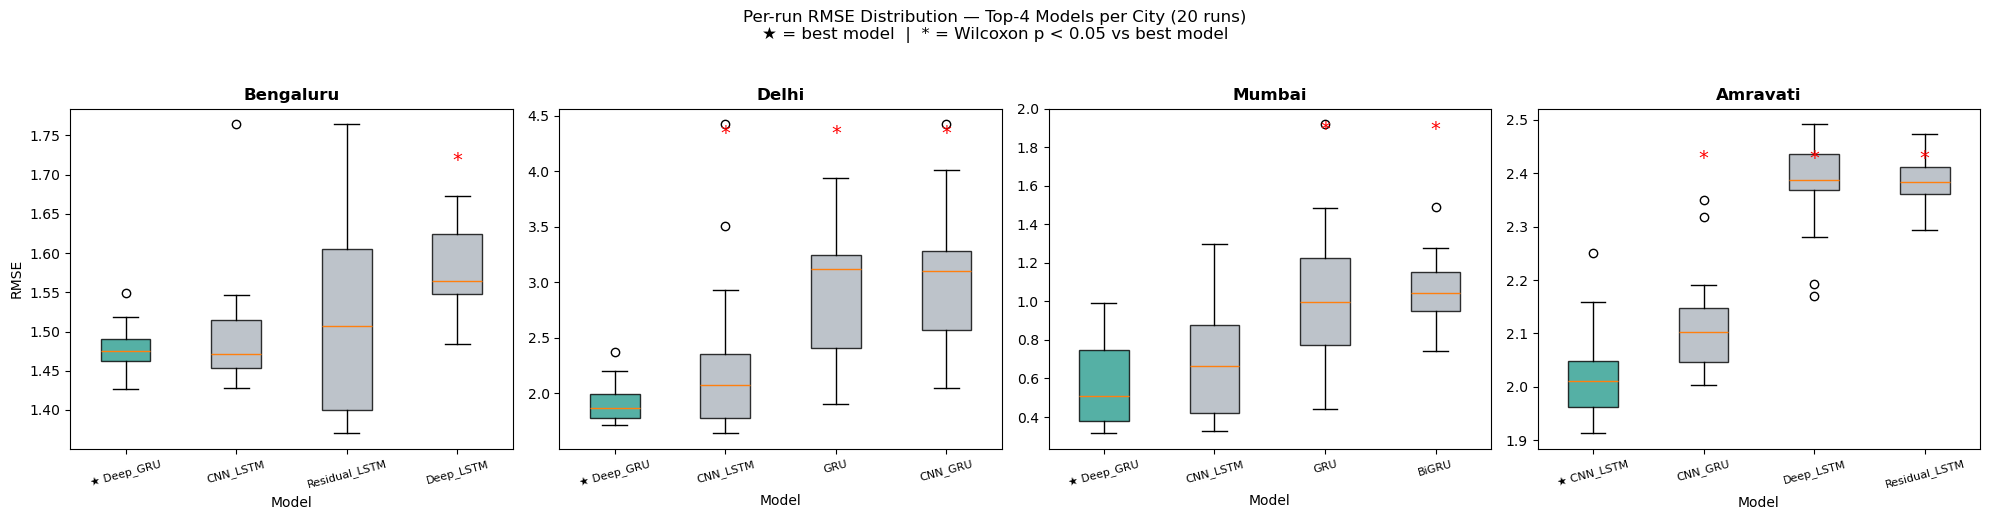

Saved → D:\Projects\Python Scripts\AQI 2026\simple_aqi\Significance_Boxplot.png


In [10]:
# ── Boxplot: per-run RMSE distribution (best vs top-3) ────────

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (city, data) in zip(axes, city_data.items()):
    best    = data['best_model']
    summary = data['summary'].sort_values('RMSE')

    # Top 4 models (best + 3 runners-up) that have per-run RMSE
    top4 = [m for m in summary['Model'].values
            if m in data['per_run_rmse']][:4]

    plot_data  = [data['per_run_rmse'][m] for m in top4]
    labels     = [f'\u2605 {m}' if m == best else m for m in top4]

    bp = ax.boxplot(plot_data, labels=labels, patch_artist=True, notch=False)

    colors = ['#2a9d8f' if m == best else '#adb5bd' for m in top4]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_title(city, fontsize=12, fontweight='bold')
    ax.set_ylabel('RMSE' if city == 'Bengaluru' else '')
    ax.set_xlabel('Model')
    ax.tick_params(axis='x', labelsize=8, rotation=15)

    # Annotate Wilcoxon significance
    city_wl = wl_df[wl_df['City'] == city]
    for j, m in enumerate(top4[1:], start=1):
        row = city_wl[city_wl['Comparison_Model'] == m]
        if len(row) and row.iloc[0]['Significant'] == 'Yes':
            p = row.iloc[0]['p_value']
            ax.text(j+1, ax.get_ylim()[1]*0.97,
                    '*' if float(p) < 0.05 else '',
                    ha='center', va='top', fontsize=14, color='red')

plt.suptitle(
    'Per-run RMSE Distribution — Top-4 Models per City (20 runs)\n'
    '★ = best model  |  * = Wilcoxon p < 0.05 vs best model',
    fontsize=12, y=1.03
)
plt.tight_layout()

fig_path = os.path.join(BASE_DIR, 'Significance_Boxplot.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

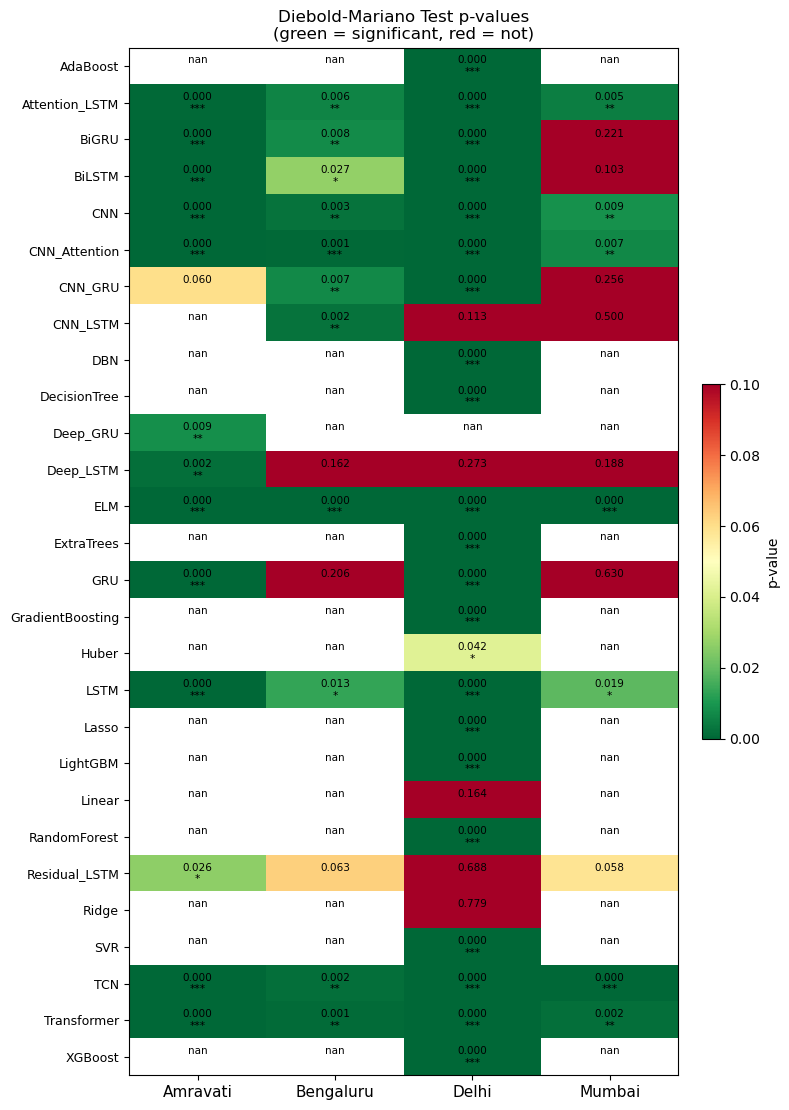

Saved → D:\Projects\Python Scripts\AQI 2026\simple_aqi\DM_pvalue_heatmap.png


In [11]:
# ── Heatmap: DM p-values (all models × all cities) ────────────

# Build numeric pivot
dm_p_pivot = dm_df.pivot_table(
    index='Comparison_Model', columns='City', values='p_value', aggfunc='first'
).astype(float)

fig, ax = plt.subplots(figsize=(8, max(5, len(dm_p_pivot) * 0.4)))
im = ax.imshow(dm_p_pivot.values, aspect='auto', cmap='RdYlGn_r',
               vmin=0, vmax=0.1)

ax.set_xticks(range(len(dm_p_pivot.columns)))
ax.set_xticklabels(dm_p_pivot.columns, fontsize=11)
ax.set_yticks(range(len(dm_p_pivot.index)))
ax.set_yticklabels(dm_p_pivot.index, fontsize=9)
ax.set_title('Diebold-Mariano Test p-values\n(green = significant, red = not)', fontsize=12)

# Annotate cells
for i in range(dm_p_pivot.shape[0]):
    for j in range(dm_p_pivot.shape[1]):
        val = dm_p_pivot.values[i, j]
        txt = f'{val:.3f}'
        star = '***' if val < 0.001 else ('**' if val < 0.01 else ('*' if val < 0.05 else ''))
        ax.text(j, i, f'{txt}\n{star}', ha='center', va='center',
                fontsize=7.5, color='black')

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label='p-value')
plt.tight_layout()

fig_path = os.path.join(BASE_DIR, 'DM_pvalue_heatmap.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

In [12]:
# ── Wilcoxon between ablation decomposition methods ───────────
# Compares Hybrid_ICEEMDAN_VMD vs each other method using
# per-run RMSE saved by ablation_study.ipynb

ablation_wl_rows = []

for city in CITIES:
    ab_dir = os.path.join(BASE_DIR, city, 'results', 'h1', 'ablation')
    if not os.path.exists(ab_dir):
        print(f"  ⚠️  {city}: ablation results not found — run ablation_study.ipynb first")
        continue

    METHODS = ['No_Decomp', 'EMD', 'CEEMDAN', 'VMD', 'ICEEMDAN', 'Hybrid_ICEEMDAN_VMD']

    # Load per-run RMSE for each method
    ab_rmse = {}
    for method in METHODS:
        fpath = os.path.join(ab_dir, f'{method}.csv')
        if os.path.exists(fpath):
            ab_rmse[method] = pd.read_csv(fpath)['RMSE'].values

    if 'Hybrid_ICEEMDAN_VMD' not in ab_rmse:
        print(f"  ⚠️  {city}: Hybrid ablation results missing")
        continue

    hybrid_rmse = ab_rmse['Hybrid_ICEEMDAN_VMD']

    for method, rmse_vals in ab_rmse.items():
        if method == 'Hybrid_ICEEMDAN_VMD': continue
        if len(rmse_vals) != len(hybrid_rmse): continue
        try:
            w_stat, w_p = wilcoxon(hybrid_rmse, rmse_vals, alternative='less')
        except Exception:
            w_stat, w_p = np.nan, np.nan

        ablation_wl_rows.append({
            'City':         city,
            'Hybrid_mean_RMSE':  round(float(np.mean(hybrid_rmse)), 4),
            'Method':       method,
            'Method_mean_RMSE': round(float(np.mean(rmse_vals)), 4),
            'W_Statistic':  round(float(w_stat), 2) if not np.isnan(w_stat) else 'NA',
            'p_value':      round(float(w_p), 4)    if not np.isnan(w_p)    else 'NA',
            'Significant':  'Yes' if (not np.isnan(w_p) and w_p < ALPHA) else 'No',
        })

if ablation_wl_rows:
    ab_wl_df = pd.DataFrame(ablation_wl_rows)
    print(ab_wl_df.to_string(index=False))
    ab_wl_df.to_excel(os.path.join(BASE_DIR, 'Ablation_Wilcoxon.xlsx'), index=False)
    print(f"\nSaved → {os.path.join(BASE_DIR, 'Ablation_Wilcoxon.xlsx')}")
else:
    print('Run ablation_study.ipynb first, then re-run this cell.')

  ⚠️  Bengaluru: ablation results not found — run ablation_study.ipynb first
  ⚠️  Delhi: ablation results not found — run ablation_study.ipynb first
  ⚠️  Mumbai: ablation results not found — run ablation_study.ipynb first
  ⚠️  Amravati: ablation results not found — run ablation_study.ipynb first
Run ablation_study.ipynb first, then re-run this cell.
